In [1]:
import sys
import os
sys.path.append('/project/GCRB/Hon_lab/s223695/Data_project/Perturb_seq_shared/')

import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.cluster import KMeans
import scipy.stats
from scipy.stats import hypergeom
from sklearn.metrics import pairwise_distances
from itertools import combinations

from sklearn.manifold import MDS,Isomap,TSNE
from sklearn.cluster import AffinityPropagation,AgglomerativeClustering

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize' : 'large',
                     'pdf.fonttype' : 42
                    }) 
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec

from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

import gc
import warnings
import time
import pickle
import json
import re

from sklearn.metrics import pairwise_distances
from multiprocessing import Pool
import torch

from importlib import reload
import util_functions

from adjustText import adjust_text
import umap

warnings.simplefilter("ignore")

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
json_fp = "./config.json"
with open(json_fp, 'r') as fp:
    config = json.load(fp)
    input_file = config["input_data"]["input_file"]
    
sgRNA_file = config["input_data"]["sgRNA_file"]

gRNA_dict_file = config["user_defined_data"]["gRNA_dict_file"]
pca_file = config["user_defined_data"]["pca_file"]
annotation_file = config["user_defined_data"]["annotation_file"]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

(X,gRNA_dict) = util_functions.load_files(input_file,sgRNA_file,gRNA_dict_file,pca_file)

read input
read pickle
read from dictionary


In [3]:
expression_ann = sc.read_h5ad(input_file)

In [4]:
expression_ann

AnnData object with n_obs × n_vars = 957653 × 34550
    obs: 'percent_RP', 'n_counts_RP', 'n_counts_all', 'louvain'
    var: 'gene_ids', 'feature_types', 'genome', 'n_counts', 'mean', 'std'
    uns: 'log1p', 'louvain', 'louvain_colors', 'louvain_sizes', 'neighbors', 'paga', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [5]:
mod_index = np.where(expression_ann.var.index == "ELMSAN1")[0][0]

In [6]:
index_list = np.array(expression_ann.var.index)
index_list[mod_index] = "MIDEAS"

In [7]:
expression_ann.var.index = index_list

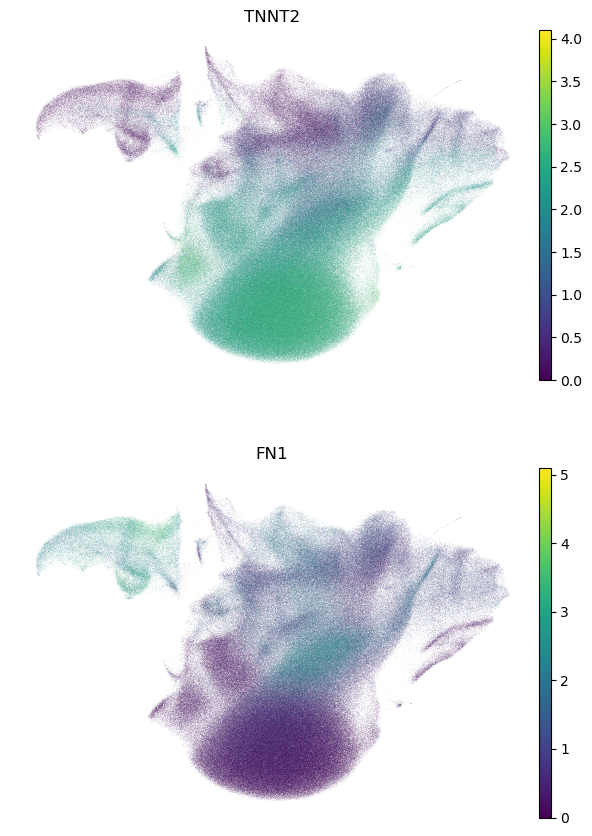

In [8]:
ax = sc.pl.umap(expression_ann,color=["TNNT2","FN1"],
                show=False,ncols=1
               )
for pos in ["top","right","bottom","left"]:
    ax[0].spines[pos].set_visible(False)
    ax[1].spines[pos].set_visible(False)
ax[0].set_xlabel("")
ax[0].set_ylabel("")
ax[1].set_xlabel("")
ax[1].set_ylabel("")

plt.savefig("./figures/CP2_umap.png",transparent=True)

In [9]:
expression_ann.var

,gene_ids,feature_types,genome,n_counts,mean,std
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38,445.0,0.000305,0.014944
AL627309.1,ENSG00000238009,Gene Expression,GRCh38,5847.0,0.003803,0.051546
AL627309.3,ENSG00000239945,Gene Expression,GRCh38,19.0,0.000014,0.003308
AL627309.2,ENSG00000239906,Gene Expression,GRCh38,112.0,0.000078,0.007800
AL627309.5,ENSG00000241860,Gene Expression,GRCh38,23507.0,0.015306,0.103312
...,...,...,...,...,...,...
AC136616.2,ENSG00000277761,Gene Expression,GRCh38,5.0,0.000004,0.001632
AC023491.2,ENSG00000278633,Gene Expression,GRCh38,13.0,0.000008,0.002314
AC007325.1,ENSG00000276017,Gene Expression,GRCh38,10.0,0.000008,0.002830
AC007325.4,ENSG00000278817,Gene Expression,GRCh38,9592.0,0.006339,0.066702


In [10]:
sgRNA_outlier_clear_df = pd.read_csv("./Step1_sgRNA_outlier_pval_clear.csv",index_col=0)

In [11]:
clear_sgRNA_list = sgRNA_outlier_clear_df.index.tolist()

In [12]:
pval_target_df = pd.read_csv("./Step2_pval_target_significant.csv")
sig_target_list = np.unique(pval_target_df["region_name"])

In [13]:
annotation_df = pd.read_csv(annotation_file,index_col=0)
annotation_df.head()

,Unnamed: 0,guide_chr,guide_start,guide_end,score,strand,protospacer_target,intended_target_region,gene_target,source,closest_gene,closest_dist,closest_gene_target,closest_dist_target
0,0,chr9,130713821,130713839,.,+,chr9:130713821-130713839(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
1,1,chr9,130713809,130713827,.,+,chr9:130713809-130713827(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
2,2,chr9,130713859,130713877,.,+,chr9:130713859-130713877(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
3,3,chr9,130714246,130714264,.,-,chr9:130714246-130714264(-),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
4,4,chr9,130713865,130713883,.,+,chr9:130713865-130713883(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993


In [14]:
all_region = np.unique(annotation_df["gene_target"])
print("Promoter:",np.sum([not x.startswith("Element") for x in all_region]))
print("Enhancer:",np.sum([x.startswith("Element") for x in all_region]))

Promoter: 281
Enhancer: 1267


In [15]:
enhancer_info_file = "/project/GCRB/Hon_lab/s223695/Data_project/20240903_CP2/Step4_enhancer_pval.csv"
enhancer_info = pd.read_csv(enhancer_info_file,index_col=0)

In [16]:
enhancer_info.head()

,promoter,enhancer,edist,pro_enh_dist,promoter_nontarget_pval,enhancer_nontarget_pval,promoter_nontarget_edist,enhancer_nontarget_edist,total_cell_num
0,ACVR2B_P1P2,Element902,16.014038,65483,5.0,0.786854,16.725189,2.208496,4162
1,ACVR2B_P1P2,Element903,20.124756,68764,5.0,1.147764,16.725189,2.895355,3901
2,ACVR2B_P1P2,Element904,15.666748,75678,5.0,0.229840,16.725189,1.197150,4066
3,ACVR2B_P1P2,Element905,13.641968,80241,5.0,0.912538,16.725189,2.190228,4344
4,ACVR2B_P1P2,OR10H2,16.420532,-1,5.0,-1.000000,16.725189,-1.000000,3327


In [17]:
enhancer_info

,promoter,enhancer,edist,pro_enh_dist,promoter_nontarget_pval,enhancer_nontarget_pval,promoter_nontarget_edist,enhancer_nontarget_edist,total_cell_num
0,ACVR2B_P1P2,Element902,16.014038,65483,5.0,0.786854,16.725189,2.208496,4162
1,ACVR2B_P1P2,Element903,20.124756,68764,5.0,1.147764,16.725189,2.895355,3901
2,ACVR2B_P1P2,Element904,15.666748,75678,5.0,0.229840,16.725189,1.197150,4066
3,ACVR2B_P1P2,Element905,13.641968,80241,5.0,0.912538,16.725189,2.190228,4344
4,ACVR2B_P1P2,OR10H2,16.420532,-1,5.0,-1.000000,16.725189,-1.000000,3327
...,...,...,...,...,...,...,...,...,...
1313,ZSCAN10_P1P2,OR10H2,42.410889,-1,5.0,-1.000000,37.051440,-1.000000,2836
1314,ZSCAN10_P1P2,OR10K1,38.437622,-1,5.0,-1.000000,37.051440,-1.000000,2670
1315,ZSCAN10_P1P2,OR10V1,38.271240,-1,5.0,-1.000000,37.051440,-1.000000,2605
1316,ZSCAN10_P1P2,OR14J1,38.242798,-1,5.0,-1.000000,37.051440,-1.000000,2811


In [18]:
pro_enh_combis = enhancer_info.loc[:,["promoter","enhancer"]].values

In [19]:
annotation_df

,Unnamed: 0,guide_chr,guide_start,guide_end,score,strand,protospacer_target,intended_target_region,gene_target,source,closest_gene,closest_dist,closest_gene_target,closest_dist_target
0,0,chr9,130713821,130713839,.,+,chr9:130713821-130713839(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
1,1,chr9,130713809,130713827,.,+,chr9:130713809-130713827(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
2,2,chr9,130713859,130713877,.,+,chr9:130713859-130713877(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
3,3,chr9,130714246,130714264,.,-,chr9:130714246-130714264(-),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
4,4,chr9,130713865,130713883,.,+,chr9:130713865-130713883(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13877,13877,chrX,73563380,73563399,.,-,chrX:73563380-73563399(-),chrX:73562916-73563799,Element1268,TF,CHIC1,160,CDX4,116304
13878,13878,chrX,73563497,73563516,.,-,chrX:73563497-73563516(-),chrX:73562916-73563799,Element1268,TF,CHIC1,160,CDX4,116304
13879,13879,chrX,73563538,73563557,.,+,chrX:73563538-73563557(+),chrX:73562916-73563799,Element1268,TF,CHIC1,160,CDX4,116304
13880,13880,chrX,73563630,73563649,.,+,chrX:73563630-73563649(+),chrX:73562916-73563799,Element1268,TF,CHIC1,160,CDX4,116304


In [20]:
promoter_list = np.unique(pro_enh_combis[:,0])
pro_enh_dict = {}
for pro_name_tmp in promoter_list:
    pro_target_gene = annotation_df[annotation_df["gene_target"]==pro_name_tmp]["closest_gene_target"].values[0]
    pro_idx = np.where(pro_enh_combis[:,0]==pro_name_tmp)[0]
    pro_enh_dict[pro_name_tmp] = [pro_target_gene,pro_enh_combis[pro_idx,1]]

In [21]:
target_list = np.unique(annotation_df["closest_gene_target"])

All genes exist in h5ad file

In [22]:
gRNA_region_dict = {}

OR_gRNA_list = [i for i in gRNA_dict.keys() if i.startswith("OR")]
for gRNA_tmp in OR_gRNA_list:
    gene_name = gRNA_tmp.split("-")[0]
    
    if gene_name in gRNA_region_dict.keys():
        gRNA_region_dict[gene_name] += [gRNA_tmp]
    else:
        gRNA_region_dict[gene_name] = [gRNA_tmp]

for index,row in annotation_df.iterrows():
    if row.protospacer_target in clear_sgRNA_list:
        if row.intended_target_region in gRNA_region_dict.keys():
            gRNA_region_dict[row.intended_target_region] += [row.protospacer_target]
        else:
            gRNA_region_dict[row.intended_target_region] = [row.protospacer_target]
for key in gRNA_region_dict.keys():
    gRNA_region_dict[key] = np.unique(gRNA_region_dict[key])

In [23]:
def convert_name_region(target_name):
    if re.match("^OR[0-9]",target_name)!=None:
        return target_name
    else:
        return annotation_df[annotation_df["gene_target"]==target_name]["intended_target_region"].values[0]
    

In [24]:
non_target_df = pd.read_csv("./Step2_non_targeting_gRNA_clean.csv")
gRNA_region_dict["non-targeting"] = non_target_df.values.reshape(-1).tolist()

In [25]:
cell_per_region_dict = {}
for key in gRNA_region_dict.keys():
    cell_list_tmp = np.concatenate([gRNA_dict[i] for i in gRNA_region_dict[key]])
    cell_per_region_dict[key] = np.unique(cell_list_tmp)

In [26]:
exp_arr = np.exp(expression_ann.raw.X[:10].toarray())-1
total_count = np.mean(np.sum(exp_arr,axis=1))
cpm_factor = 1000000/total_count

In [27]:
target_index = np.argwhere(np.isin(expression_ann.var.index,target_list)).reshape(-1)
target_list_tmp = np.array(expression_ann.var.index.tolist())[target_index]
target_name_idx_dict = dict(zip(target_list_tmp,target_index))

ext_arr = np.exp(expression_ann.raw.X[:,target_index].toarray())-1
ext_arr = pd.DataFrame(ext_arr,
                       index=expression_ann.obs.index,
                       columns=target_list_tmp
                      )

In [28]:
expression_element_df_total = pd.DataFrame([])

for target_pro in tqdm(pro_enh_dict.keys()):
    expression_element_df = pd.DataFrame([])
    target_gene = pro_enh_dict[target_pro][0]
    
    target_element_list = [target_pro]
    target_element_list = np.append(np.unique(pro_enh_dict[target_pro][1]),target_element_list)
    target_element_list = np.append(["non-targeting"],target_element_list)

    for target_element in target_element_list:
        if target_element=="non-targeting":
            target_region = "non-targeting"
        else:
            target_region = convert_name_region(target_element)
        if not target_region in cell_per_region_dict.keys():
            continue
        target_cell = cell_per_region_dict[target_region]

        expression_array = ext_arr.loc[target_cell,target_gene]*cpm_factor
        expression_element_df.at[target_element,"expression_mean"] = np.mean(expression_array)
        expression_element_df.at[target_element,"expression_median"] = np.median(expression_array)

    expression_element_df = expression_element_df.reset_index()
    expression_element_df["target_gene"] = target_gene

    non_target_exp = expression_element_df.at[0,"expression_mean"]
    expression_element_df["expression_mean_norm"] = \
        expression_element_df["expression_mean"] / non_target_exp
    expression_element_df["expression_mean_log10"] = np.log10(expression_element_df["expression_mean"])
    expression_element_df_total = pd.concat([expression_element_df_total,expression_element_df])

100%|██████████| 89/89 [00:12<00:00,  7.08it/s]


In [29]:
expression_element_df_total.head(15)

,index,expression_mean,expression_median,target_gene,expression_mean_norm,expression_mean_log10
0,non-targeting,78.159950,0.0,ACVR2B,1.000000,1.892984
1,Element902,83.014420,0.0,ACVR2B,1.062109,1.919154
2,Element903,74.111351,0.0,ACVR2B,0.948201,1.869885
3,Element904,88.973083,0.0,ACVR2B,1.138346,1.949259
4,Element905,70.112206,0.0,ACVR2B,0.897035,1.845794
5,OR10H2,76.725677,0.0,ACVR2B,0.981650,1.884941
6,OR10K1,79.901962,0.0,ACVR2B,1.022288,1.902557
7,OR10V1,80.799446,0.0,ACVR2B,1.033770,1.907408
8,OR14J1,66.794327,0.0,ACVR2B,0.854585,1.824740
9,OR2A2,85.510170,0.0,ACVR2B,1.094041,1.932018


In [30]:
expression_element_df_total = expression_element_df_total.reset_index(drop=True)

In [31]:
expression_element_df_total.head()

,index,expression_mean,expression_median,target_gene,expression_mean_norm,expression_mean_log10
0,non-targeting,78.159950,0.0,ACVR2B,1.000000,1.892984
1,Element902,83.014420,0.0,ACVR2B,1.062109,1.919154
2,Element903,74.111351,0.0,ACVR2B,0.948201,1.869885
3,Element904,88.973083,0.0,ACVR2B,1.138346,1.949259
4,Element905,70.112206,0.0,ACVR2B,0.897035,1.845794


In [32]:
unq_list,unq_count = np.unique(expression_element_df_total["target_gene"].values,return_counts=True)

In [33]:
multiple_enhancer_target = unq_list[unq_count>3]

In [34]:
expression_multi_element_df = expression_element_df_total[np.isin(expression_element_df_total["target_gene"],multiple_enhancer_target)].copy()

In [35]:
expression_multi_element_df_nt = expression_multi_element_df[expression_multi_element_df["index"]=="non-targeting"]
expression_multi_element_df_nt = expression_multi_element_df_nt.sort_values("expression_mean")

In [36]:
expression_element_df_total.to_csv("Step5_repression_efficiency.csv")
expression_multi_element_df_nt.to_csv("Step5_repression_efficiency_nt.csv")

In [37]:
low_exp_num = np.sum(expression_multi_element_df_nt["expression_mean_log10"]<0)
gene_exp_low = expression_multi_element_df_nt["target_gene"].iloc[:low_exp_num].values
print(low_exp_num)

8


In [38]:
def get_target_name(element_name):
    return expression_element_df_total[expression_element_df_total["index"]==element_name]["target_gene"].values[0]

def get_target_exp_category(target_name):
    if target_name in gene_exp_low:
        return "low"
    else:
        return "normal"

def get_exp_val(element_name):
    return expression_element_df_total[expression_element_df_total["index"]==element_name]["expression_mean"].values[0]

def get_exp_val_norm(element_name):
    return expression_element_df_total[expression_element_df_total["index"]==element_name]["expression_mean_norm"].values[0]

In [39]:
expression_element_df_total

,index,expression_mean,expression_median,target_gene,expression_mean_norm,expression_mean_log10
0,non-targeting,78.159950,0.0,ACVR2B,1.000000,1.892984
1,Element902,83.014420,0.0,ACVR2B,1.062109,1.919154
2,Element903,74.111351,0.0,ACVR2B,0.948201,1.869885
3,Element904,88.973083,0.0,ACVR2B,1.138346,1.949259
4,Element905,70.112206,0.0,ACVR2B,0.897035,1.845794
...,...,...,...,...,...,...
1491,OR10K1,0.219635,0.0,ZSCAN10,2.233814,-0.658299
1492,OR10V1,0.000000,0.0,ZSCAN10,0.000000,-inf
1493,OR14J1,0.000000,0.0,ZSCAN10,0.000000,-inf
1494,OR2A2,0.171561,0.0,ZSCAN10,1.744878,-0.765581


In [40]:
get_target_exp_category("MYL7")

'normal'

In [41]:
expression_multi_element_df_nt["expression_category"] = \
    expression_multi_element_df_nt["target_gene"].apply(get_target_exp_category)

In [42]:
expression_multi_element_df_nt.head()

,index,expression_mean,expression_median,target_gene,expression_mean_norm,expression_mean_log10,expression_category
191,non-targeting,0.002018,0.0,FOXD3,1.0,-2.695097,low
199,non-targeting,0.002018,0.0,FOXD3,1.0,-2.695097,low
1171,non-targeting,0.098128,0.0,TFAP2C,1.0,-1.008207,low
1479,non-targeting,0.098323,0.0,ZSCAN10,1.0,-1.007346,low
347,non-targeting,0.121550,0.0,IKZF1,1.0,-0.915244,low


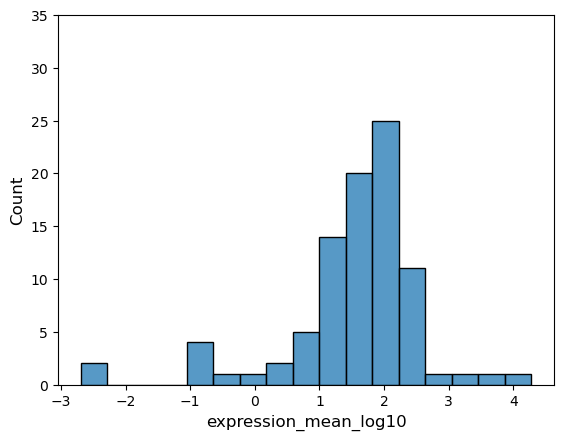

In [43]:
sns.histplot(data=expression_multi_element_df_nt,
             x="expression_mean_log10"
            )
plt.ylim(0,35)
plt.savefig("Step5_histgram_nontarget.pdf")

<Axes: xlabel='expression_mean_log10', ylabel='Count'>

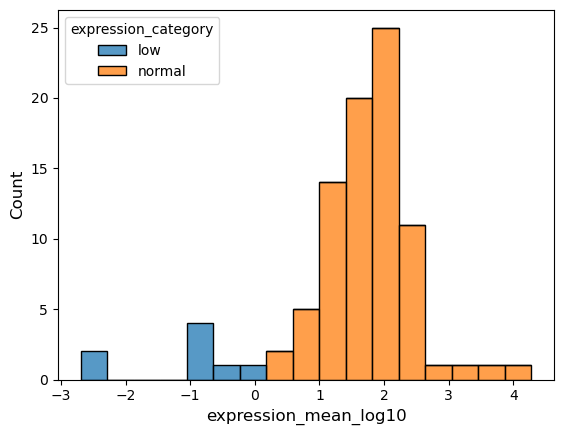

In [44]:
sns.histplot(data=expression_multi_element_df_nt,
             x="expression_mean_log10",hue="expression_category",multiple="stack"
            )

In [45]:
expression_multi_element_df_nt

,index,expression_mean,expression_median,target_gene,expression_mean_norm,expression_mean_log10,expression_category
191,non-targeting,0.002018,0.000000,FOXD3,1.0,-2.695097,low
199,non-targeting,0.002018,0.000000,FOXD3,1.0,-2.695097,low
1171,non-targeting,0.098128,0.000000,TFAP2C,1.0,-1.008207,low
1479,non-targeting,0.098323,0.000000,ZSCAN10,1.0,-1.007346,low
347,non-targeting,0.121550,0.000000,IKZF1,1.0,-0.915244,low
...,...,...,...,...,...,...,...
502,non-targeting,425.782135,343.229767,MEF2A,1.0,2.629188,normal
238,non-targeting,622.158630,504.540802,GATA4,1.0,2.793901,normal
1231,non-targeting,2832.088379,2735.042969,TNNT2,1.0,3.452107,normal
612,non-targeting,4469.695801,3790.271484,MYH6,1.0,3.650278,normal


### Calculate normalized energy distances

In [46]:
enhancer_info

,promoter,enhancer,edist,pro_enh_dist,promoter_nontarget_pval,enhancer_nontarget_pval,promoter_nontarget_edist,enhancer_nontarget_edist,total_cell_num
0,ACVR2B_P1P2,Element902,16.014038,65483,5.0,0.786854,16.725189,2.208496,4162
1,ACVR2B_P1P2,Element903,20.124756,68764,5.0,1.147764,16.725189,2.895355,3901
2,ACVR2B_P1P2,Element904,15.666748,75678,5.0,0.229840,16.725189,1.197150,4066
3,ACVR2B_P1P2,Element905,13.641968,80241,5.0,0.912538,16.725189,2.190228,4344
4,ACVR2B_P1P2,OR10H2,16.420532,-1,5.0,-1.000000,16.725189,-1.000000,3327
...,...,...,...,...,...,...,...,...,...
1313,ZSCAN10_P1P2,OR10H2,42.410889,-1,5.0,-1.000000,37.051440,-1.000000,2836
1314,ZSCAN10_P1P2,OR10K1,38.437622,-1,5.0,-1.000000,37.051440,-1.000000,2670
1315,ZSCAN10_P1P2,OR10V1,38.271240,-1,5.0,-1.000000,37.051440,-1.000000,2605
1316,ZSCAN10_P1P2,OR14J1,38.242798,-1,5.0,-1.000000,37.051440,-1.000000,2811


In [47]:
with PdfPages("Step5_repression_edist_analysis.pdf") as pdf:
    for target_name in tqdm(multiple_enhancer_target):
        expression_element_df_selected = expression_element_df_total[expression_element_df_total["target_gene"]==target_name]
        target_region_tmp = \
            expression_element_df_selected[expression_element_df_selected["index"].str.contains(target_name+"_")]["index"].values
        
        target_region_tmp = list(set(target_region_tmp) & set(sig_target_list))
        for target_region in target_region_tmp: 
            non_target_exp = \
                expression_element_df_selected[expression_element_df_selected["index"]=="non-targeting"]["expression_mean"].values[0]
            target_exp = \
                expression_element_df_selected[expression_element_df_selected["index"]==target_region]["expression_mean"].values[0]  
            
            fig = plt.figure(figsize=(8, 12), constrained_layout=False)
            gs = GridSpec(4,1)
            ax1 = fig.add_subplot(gs[0])
            ax2 = fig.add_subplot(gs[1])
            ax3 = fig.add_subplot(gs[2:])

            sns.barplot(expression_element_df_selected.iloc[1:],x="index",y="expression_mean_norm",ax=ax1)
            ax1.set_ylim(0,1.2)
            ax1.axhline(1.0,linestyle="--",c="black")

            sns.barplot(expression_element_df_selected.iloc[1:],x="index",y="expression_mean",ax=ax2)
            ax2.axhline(non_target_exp,linestyle="--",c="black")

            enhancer_info_selected = \
                enhancer_info.loc[enhancer_info["promoter"]==target_region,["promoter",
                                                                            "enhancer",
                                                                            "promoter_nontarget_edist",
                                                                            "edist"]].copy()
            if enhancer_info_selected.shape[0]==0:
                continue

            enhancer_info_selected["expression_level"] = \
                    enhancer_info_selected["enhancer"].apply(lambda x: get_exp_val(x))
            
            non_target_edist = enhancer_info_selected["promoter_nontarget_edist"].values[0]
            non_target_df = pd.DataFrame(["Promoter","non-targeting",non_target_edist,non_target_edist,
                                  expression_element_df_selected["expression_mean"].values[0]]).T
            non_target_df.columns = enhancer_info_selected.columns

            enhancer_info_selected = \
                pd.concat([enhancer_info_selected,non_target_df],
                          join="inner"
                         )
            
            sns.scatterplot(data=enhancer_info_selected,x="expression_level",y="edist",
                            edgecolor=None,s=50,ax=ax3)
            ax3.axvline(non_target_exp,linestyle="--",c="black")
            ax3.axvline(target_exp,linestyle="--",c="black")
            y_low,y_high = ax3.get_ylim()
            unit= (y_high-y_low)/100
            for row in enhancer_info_selected.itertuples():
                ax3.text(row.expression_level,row.edist+unit,row.enhancer)
            plt.tight_layout()
            pdf.savefig()
            plt.close()

100%|██████████| 86/86 [00:28<00:00,  3.05it/s]


<h4>Normalize distance and expression level</h4>

In [48]:
enhancer_info.head()

,promoter,enhancer,edist,pro_enh_dist,promoter_nontarget_pval,enhancer_nontarget_pval,promoter_nontarget_edist,enhancer_nontarget_edist,total_cell_num
0,ACVR2B_P1P2,Element902,16.014038,65483,5.0,0.786854,16.725189,2.208496,4162
1,ACVR2B_P1P2,Element903,20.124756,68764,5.0,1.147764,16.725189,2.895355,3901
2,ACVR2B_P1P2,Element904,15.666748,75678,5.0,0.229840,16.725189,1.197150,4066
3,ACVR2B_P1P2,Element905,13.641968,80241,5.0,0.912538,16.725189,2.190228,4344
4,ACVR2B_P1P2,OR10H2,16.420532,-1,5.0,-1.000000,16.725189,-1.000000,3327


In [49]:
enhancer_info["edist_norm"] = enhancer_info["edist"]/enhancer_info["promoter_nontarget_edist"]

In [50]:
res_df = []
for target_name in tqdm(multiple_enhancer_target):
    expression_element_df_selected = expression_element_df_total[expression_element_df_total["target_gene"]==target_name]
    target_region = expression_element_df_selected[expression_element_df_selected["index"].str.contains("_")]["index"].values[-1]
    
    enhancer_info_selected = enhancer_info[enhancer_info["promoter"]==target_region].copy()
    enhancer_info_selected["target_name"] = \
        enhancer_info_selected["enhancer"].apply(lambda x: get_target_name(x))
    enhancer_info_selected["expression_category"] = \
        enhancer_info_selected["target_name"].apply(get_target_exp_category)
    
    enhancer_info_selected["expression_level"] = \
        enhancer_info_selected["enhancer"].apply(lambda x: get_exp_val(x))
    enhancer_info_selected["expression_level_norm"] = \
        enhancer_info_selected["enhancer"].apply(lambda x: get_exp_val_norm(x))
    res_df.append(enhancer_info_selected)

100%|██████████| 86/86 [00:01<00:00, 85.28it/s]


In [51]:
enhancer_info_norm = pd.concat(res_df)
enhancer_info_norm["is_NT"] = enhancer_info_norm["enhancer"].str.startswith("OR")

In [52]:
enhancer_info_norm_nc = enhancer_info_norm[enhancer_info_norm["is_NT"]]
enhancer_info_norm_target = enhancer_info_norm[~enhancer_info_norm["is_NT"]]

In [53]:
## all_nc_num = enhancer_info_norm_nc.shape[0]
print("all",all_nc_num)

for cutoff_norm_tmp in np.arange(0.5,1,0.05):
    false_pos_num = enhancer_info_norm_nc[enhancer_info_norm_nc["edist_norm"]<cutoff_norm_tmp].shape[0]
    print(round(cutoff_norm_tmp,3),false_pos_num,round(false_pos_num/all_nc_num,3))

NameError: name 'all_nc_num' is not defined

In [ ]:
fig,ax=plt.subplots(2,1,figsize=(8,4))
bin_plt = np.arange(0,2,0.05)
sns.histplot(enhancer_info_norm_nc["edist_norm"],stat="percent",
             bins=bin_plt,ax=ax[0],color=sns.color_palette("tab10")[0])
sns.histplot(enhancer_info_norm_target["edist_norm"],stat="percent",
             bins=bin_plt,ax=ax[1],color=sns.color_palette("tab10")[1])
ax[0].set_title("OT_TF_pair")
ax[1].set_title("Element_TF_pair")
ax[0].set_xlim(0,2)
ax[1].set_xlim(0,2)
plt.tight_layout()
plt.savefig("./figures/normalized_edist_compare.pdf")

In [ ]:
enhancer_info_norm_target.head()

#### Make plot for selected enhancer

In [ ]:
gene_element_list= [
    ["MESP1_P1P2","Element414","MESP1"],
    ["MESP1_P1P2","Element416","MESP1"],
    ["LZTS1_P1P2","Element1186","LZTS1"],
    ["ZIC5_P1P2","Element309","ZIC5"],
    ["TFAP4_P1P2","Element483","TFAP4"]]

In [ ]:
expression_element_df_total

In [ ]:
fig,ax = plt.subplots(1,5,figsize=(20,6))
for i,(prom,element,gene_name) in enumerate(gene_element_list):
    target_row = expression_element_df_total[
                        expression_element_df_total["target_gene"]==gene_name
    ].copy()
    
    rel_exp_nt = target_row[target_row["index"]=="non-targeting"]["expression_mean"].values[0]
    rel_exp_prom = target_row[target_row["index"]==prom]["expression_mean"].values[0]
    rel_exp_enh = target_row[target_row["index"]==element]["expression_mean"].values[0]
    
    ax[i].bar(x=["non-targeting",prom,element],
              height=[rel_exp_nt,rel_exp_prom,rel_exp_enh])
    ax[i].set_title(gene_name)
    ax[i].set_ylabel("mean CPM")
plt.tight_layout()
plt.savefig("./figures/weak_enhancer_exp.pdf")

### compare with denovo non-coding variant

In [ ]:
#de novo variant
region_case = pd.read_csv("./region_with_case.bed",sep="\t",header=None)
region_case.columns = ["chrom","start","end","name"]
region_control = pd.read_csv("./region_with_control.bed",sep="\t",header=None)
region_control.columns = ["chrom","start","end","name"]

In [ ]:
enhancer_info_norm_clear["dnv_case"] = \
    np.isin(enhancer_info_norm_clear["enhancer"],region_case["name"])
enhancer_info_norm_clear["dnv_control"] =  \
    np.isin(enhancer_info_norm_clear["enhancer"],region_control["name"])

In [ ]:
print(np.sum(enhancer_info_norm_clear["dnv_case"]))

In [ ]:
enhancer_info_norm.to_csv("Step5_enhancer_pval_info.csv")

<h4>Compare with MPRA result</h4>

In [ ]:
element_dnv_list = ["Element539","Element1258","Element1167","Element1173","Element307",
                    "Element954","Element866","Element781","Element1125","Element160",
                    "Element214","Element573","Element825","Element752"
                   ]
region_dnv_list = [convert_name_region(x) for x in element_dnv_list]

In [ ]:
def is_overlap(region_1,region_2):
    chr1 = region_1.split(":")[0]
    start1 = region_1.split(":")[1].split("-")[0]
    end1 = region_1.split(":")[1].split("-")[1]
    
    chr2 = region_2.split(":")[0]
    start2 = region_2.split(":")[1].split("-")[0]
    end2 = region_2.split(":")[1].split("-")[1]
    
    if chr1 != chr2:
        return False
    else:
        return max(start1, start2) < min(end1, end2)

In [ ]:
is_overlap(region_dnv_list[0],region_dnv_list[1])

In [ ]:
mpra_result = pd.read_csv("Xiao_CHD_DNV_Diff.csv")

In [ ]:
select_df = mpra_result[mpra_result["regions(hg38)"].apply(lambda x: is_overlap(region_dnv_list[0],x))]

In [ ]:
res_mpra_df = pd.DataFrame([],columns=["element","qval","pval","fold"])

In [ ]:
res_arr = np.array([])
for element in element_dnv_list:
    region_name = convert_name_region(element)
    select_df = mpra_result[mpra_result["regions(hg38)"].apply(lambda x: is_overlap(region_name,x))]
    if select_df.shape[0]==0:
        print("skip:"+element)
        continue
    
    region_mpra = select_df["regions(hg38)"].values[0]
    qval = select_df["qvalue"].values[0]
    pval = select_df["pvalue"].values[0]
    fold = select_df["fold"].values[0]
    
    res_mpra_df.loc[element] = [element,qval,pval,fold]
    exp_value = select_df.iloc[:,1:9].values[0]
    
    #Warning: Maybe original paper swapped the data(ref and alt). 
    exp_value = np.append(exp_value[4:],exp_value[:4])
    
    exp_value = np.exp2(exp_value)
    
    data_df = pd.DataFrame([exp_value,["ref"]*4+["alt"]*4]).T
    data_df.columns=["value","label"]

    fig,ax = plt.subplots(figsize=(10,5))
    sns.barplot(data_df,y="label",x="value",errorbar=None)
    sns.swarmplot(data_df,y="label",x="value",c="black")
    plt.title(element+" "+region_mpra)
    plt.legend(title="qval: "+str(qval)+"\n pval: "+str(pval)+"\n fold:"+str(fold))
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0],ylim[1]*1.2)
    plt.savefig("./MPRA_fig/Step5_"+element+".pdf")
    plt.close

In [ ]:
res_mpra_df["log10_qval"] = np.log10(res_mpra_df["qval"])
res_mpra_df["log10_pval"] = np.log10(res_mpra_df["pval"])

In [ ]:
res_mpra_df

In [ ]:
enhancer_info_norm_mpra = enhancer_info_norm[np.isin(enhancer_info_norm["enhancer"],res_mpra_df["element"])]

In [ ]:
enhancer_info_norm_mpra["log10_qval"] = enhancer_info_norm_mpra["enhancer"].apply(lambda x: res_mpra_df.at[x,"log10_qval"])
enhancer_info_norm_mpra["log10_pval"] = enhancer_info_norm_mpra["enhancer"].apply(lambda x: res_mpra_df.at[x,"log10_pval"])
enhancer_info_norm_mpra["fold_change"] = enhancer_info_norm_mpra["enhancer"].apply(lambda x: res_mpra_df.at[x,"fold"])
enhancer_info_norm_mpra["fold_change_abs"] = np.abs(enhancer_info_norm_mpra["fold_change"])
enhancer_info_norm_mpra["fold_change_sign"] = enhancer_info_norm_mpra["fold_change"].apply(lambda x: "Plus" if x > 0 else "Minus")

In [ ]:
enhancer_info_norm_mpra

In [ ]:
plt.xlim(-0.1,2)
plt.ylim(-0.1,2)

sns.scatterplot(data=enhancer_info_norm_clear,
                x="expression_level_norm",y="edist_norm",edgecolor=None,s=12,c="lightgray"
               )
sns.scatterplot(data=enhancer_info_norm_mpra,
                x="expression_level_norm",y="edist_norm",edgecolor=None,size="fold_change_abs",hue="fold_change_sign",
                sizes=(5, 50),palette=["blue","red"],legend="brief"
               )

plt.savefig("Step5_pro_enh_edist_expression_mpra_res.pdf")

In [ ]:
enhancer_info_norm_mpra["fold_change_abs"]

In [ ]:
enhancer_info_norm_mpra

### enhancer target analysis

In [ ]:
deg_df_file = "/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240919_WTC11_lenti_CMProduction2/pySpade/Manhattan_plots/filtered_df.csv"
deg_df = pd.read_csv(deg_df_file,index_col=0)

In [ ]:
def convert_name_region(target_name):
    return annotation_df[annotation_df["gene_target"]==target_name]["intended_target_region"].values[0]
def convert_region_name(target_region):
    return annotation_df[annotation_df["intended_target_region"]==target_region]["gene_target"].values[0]

In [ ]:
target_TF = "HOXB4"
target_region_perturb = convert_name_region("HOXB4_P1P2")
target_genes = [target_TF]+['KLHL14','KCNQ5','MAP1LC3A','NCCRP1']
test_gRNA_list = ["HOXB4_P1P2","Element616","Element622"]

# target_TF = "TBX5"
# target_region_perturb = convert_name_region("TBX5_P2")
# target_genes = [target_TF]+['TECRL','NPPA','FN1','NELL1']
# test_gRNA_list = ["TBX5_P2","Element290","Element291","Element294"]

# target_TF = "MEIS1"
# target_region_perturb = convert_name_region("MEIS1_P1P2")
# target_genes = [target_TF]+['TBX18','GAP43','FBN2','KDR']
# test_gRNA_list = ["MEIS1_P1P2","Element781"]


In [ ]:
deg_df_region = deg_df[deg_df["region"]==target_region_perturb].sort_values("Significance_score")
top5_up_genes   = deg_df_region[deg_df_region["fc"]>1].iloc[:5]["gene_names"].values
top5_down_genes = deg_df_region[deg_df_region["fc"]<1].iloc[:5]["gene_names"].values

print(top5_up_genes)
print(top5_down_genes)

In [ ]:
target_gene_index = \
    [np.where(expression_ann.var.index==x)[0] for x in target_genes]
target_gene_index = np.concatenate(target_gene_index)

In [ ]:
gRNA_name_list_target = gRNA_region_dict[target_region_perturb]
cell_name_list_target = np.concatenate([gRNA_dict[x] for x in gRNA_name_list_target])
cell_name_list_target = np.unique(cell_name_list_target)

In [ ]:
res_df = pd.DataFrame([],columns=target_genes)

non_targeting_cells_pick = np.concatenate([gRNA_dict[x] for x in gRNA_region_dict["non-targeting"]])
non_targeting_cells_pick = np.unique(non_targeting_cells_pick)
np.random.seed(1234)
non_targeting_cells_pick = np.random.choice(non_targeting_cells_pick,20000,replace=False)

non_target_cell_index = \
    np.where(expression_ann.obs.index.isin(non_targeting_cells_pick))[0]

exp_arr_nt = \
    np.exp(expression_ann.raw.X[non_target_cell_index,:][:,target_gene_index].toarray())-1

exp_arr_nt = np.mean(exp_arr_nt,axis=0)

res_df.loc["non-targeting",:] = exp_arr_nt

for target_element in tqdm(test_gRNA_list):
    target_region = convert_name_region(target_element)
    gRNA_name_list_target = gRNA_region_dict[target_region]
    cell_name_list_target = np.concatenate([gRNA_dict[x] for x in gRNA_name_list_target])
    cell_name_list_target = np.unique(cell_name_list_target)

    test_cell_index = \
        np.where(expression_ann.obs.index.isin(cell_name_list_target))[0]
    
    exp_arr_target = np.exp(expression_ann.raw.X[test_cell_index,:][:,target_gene_index].toarray())-1
    exp_arr_target = np.mean(exp_arr_target,axis=0)
    
    res_df.loc[target_element,:] = exp_arr_target

In [ ]:
for col_name in res_df.columns:
    res_df[col_name] = res_df[col_name]/res_df.at["non-targeting",col_name]
res_df = res_df.iloc[1:]

In [ ]:
res_df_melt = res_df.melt(ignore_index=False).reset_index()

In [ ]:
fig,ax = plt.subplots(figsize=(8,3))
sns.barplot(res_df_melt,x="value",y="variable",hue="index",ax=ax)
ax.axvline(x=1.0,color="black",linestyle="--")
plt.savefig("./exp_fig/"+target_TF+".pdf")

### analysis for HOXB4 and HOXB4 cluster

In [ ]:
sum_row = np.mean(np.sum(np.exp(expression_ann.raw.X[:5,:].toarray())-1,axis=1))
convert_rate = 1000000/sum_row

In [ ]:
target_TF = "HOXB4"
target_region_perturb = convert_name_region("HOXB4_P1P2")
target_genes = [target_TF]+['HOXB1','HOXB2','HOXB3','HOXB5','HOXB6','HOXB7','HOXB8']
test_gRNA_list = ["HOXB4_P1P2","Element616","Element622"]


In [ ]:
target_gene_index = \
    [np.where(expression_ann.var.index==x)[0] for x in target_genes]
target_gene_index = np.concatenate(target_gene_index)

In [ ]:
gRNA_name_list_target = gRNA_region_dict[target_region_perturb]
cell_name_list_target = np.concatenate([gRNA_dict[x] for x in gRNA_name_list_target])
cell_name_list_target = np.unique(cell_name_list_target)

In [ ]:
res_df = pd.DataFrame([],columns=target_genes)

non_targeting_cells_pick = np.concatenate([gRNA_dict[x] for x in gRNA_region_dict["non-targeting"]])
non_targeting_cells_pick = np.unique(non_targeting_cells_pick)
np.random.seed(1234)
non_targeting_cells_pick = np.random.choice(non_targeting_cells_pick,20000,replace=False)

non_target_cell_index = \
    np.where(expression_ann.obs.index.isin(non_targeting_cells_pick))[0]

exp_arr_nt = \
    np.exp(expression_ann.raw.X[non_target_cell_index,:][:,target_gene_index].toarray())-1

exp_arr_nt = np.mean(exp_arr_nt,axis=0)

res_df.loc["non-targeting",:] = exp_arr_nt

for target_element in tqdm(test_gRNA_list):
    target_region = convert_name_region(target_element)
    gRNA_name_list_target = gRNA_region_dict[target_region]
    cell_name_list_target = np.concatenate([gRNA_dict[x] for x in gRNA_name_list_target])
    cell_name_list_target = np.unique(cell_name_list_target)

    test_cell_index = \
        np.where(expression_ann.obs.index.isin(cell_name_list_target))[0]
    
    exp_arr_target = np.exp(expression_ann.raw.X[test_cell_index,:][:,target_gene_index].toarray())-1
    exp_arr_target = np.mean(exp_arr_target,axis=0)
    
    res_df.loc[target_element,:] = exp_arr_target

In [ ]:
res_df_raw = res_df.copy()

In [ ]:
for col_name in res_df.columns:
    res_df[col_name] = (res_df[col_name]+0.01)/(res_df.at["non-targeting",col_name]+0.01)
res_df = res_df.iloc[1:]

In [ ]:
res_df = res_df.loc[:,["HOXB4","HOXB2","HOXB3","HOXB5"]]
res_df_melt = res_df.melt(ignore_index=False).reset_index()

In [ ]:
fig,ax = plt.subplots(figsize=(8,3))
sns.barplot(res_df_melt,x="value",y="variable",hue="index",ax=ax)
ax.axvline(x=1.0,color="black",linestyle="--")
plt.savefig("./exp_fig/"+target_TF+"_HOXB_locus.pdf")

In [ ]:
res_df_raw_melt = res_df_raw.melt(ignore_index=False).reset_index()

In [ ]:
res_df_raw_melt["value"] = convert_rate*res_df_raw_melt["value"]

In [ ]:
fig,ax = plt.subplots(figsize=(8,6))
sns.barplot(res_df_raw_melt,x="value",y="variable",hue="index",ax=ax)
plt.savefig("./exp_fig/"+target_TF+"_all_HOXB.pdf")